**Project Statement:**   
Oil spills pose a serious threat to marine ecosystems, coastal regions, and local economies. Traditional
detection methods such as satellite image manual inspection or physical patrolling are time
consuming, labor-intensive, and often delayed. This project aims to develop an AI-powered oil spill
detection system using machine learning and satellite imagery to identify and localize oil spills
efficiently and accurately. Leveraging deep learning models such as CNNs or U-Net, the system will
analyze satellite images to detect oil spill patterns and generate segmentation maps for real-time
monitoring. This approach helps in early intervention, reducing environmental damage and supporting
emergency response.


**Outcomes**: The goal is to develop an AI-powered system that:

*   Automatically detects and segments oil spills in satellite images
*   Learns visual patterns specific to oil-contaminated regions using deep Learning
*   Produces clear segmentation masks highlighting affected areas
Assists environmental monitoring agencies in rapid oil spill detection and  intervention
*   Is deployable via a user-friendly interface for real-time use

Module 1: Data Collection

• Acquire satellite image datasets such as Sentinel-1 SAR, MODIS, or NOAA.

• Dataset Used: Oil Spill Detection Dataset on Kaggle

• Obtain labeled oil spill annotations from open environmental datasets or manually create custom segmentation masks for training.

• Organize the dataset into a structured format with separate directories for training, validation, and testing.

**NOTE**: Different dataset with pre-seggregated images & masks for Training, Testing and Validation is being used because of dataset size download issues.


In [ ]:
#STEP1: Manually download the dataset into PC
#STEP2: Upload to Google Drive
#STEP3: Mount the Google Drive and processing the dataset from Google Drive

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Module 2: Data Exploration and Data Preprocessing

• Visualize sample satellite images and study statistical properties of spill and non-spill regions.

• Resize images to standard dimensions (e.g., 256x256).

• Normalize pixel values and apply SAR-specific filters such as speckle noise reduction.

• Augment dataset through techniques like flipping, rotating, scaling, and
brightness/contrast variation.


In [ ]:
# Oil Spill Dataset - Exploration + Preprocessing
# -----------------------------------------------

#Import required Packages
import os, glob, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
# 1. Dataset paths
# ----------------------------
dataset_path = "/content/drive/MyDrive/Oil_Spill_dataset"

# Training / Validation / Test
train_images = os.path.join(dataset_path, "train/images")
train_masks  = os.path.join(dataset_path, "train/masks")

val_images   = os.path.join(dataset_path, "val/images")
val_masks    = os.path.join(dataset_path, "val/masks")

test_images  = os.path.join(dataset_path, "test/images")
test_masks   = os.path.join(dataset_path, "test/masks")

# Sample check (printing first 5 files, Helps confirm that files are properly loaded.)
print("Train Images (5):", os.listdir(train_images)[:5])
print("Train Masks (5):", os.listdir(train_masks)[:5])

# Collect file paths
train_img_paths = sorted(glob.glob(os.path.join(train_images, "*.jpg")))
train_mask_paths = sorted(glob.glob(os.path.join(train_masks, "*.png")))

val_img_paths = sorted(glob.glob(os.path.join(val_images, "*.jpg")))
val_mask_paths = sorted(glob.glob(os.path.join(val_masks, "*.png")))

test_img_paths = sorted(glob.glob(os.path.join(test_images, "*.jpg")))
test_mask_paths = sorted(glob.glob(os.path.join(test_masks, "*.png")))

print("Train:", len(train_img_paths), "images,", len(train_mask_paths), "masks")  #this checks number of images and masks for all sets
print("Val:", len(val_img_paths), "images,", len(val_mask_paths), "masks")
print("Test:", len(test_img_paths), "images,", len(test_mask_paths), "masks")

#If images and masks match in count. If the dataset is balanced across splits.

Train Images (5): ['Oil (1031).jpg', 'Oil (1004).jpg', 'Oil (1081).jpg', 'Oil (104).jpg', 'Oil (1052).jpg']
Train Masks (5): ['Oil (1027).png', 'Oil (1089).png', 'Oil (1034).png', 'Oil (104).png', 'Oil (1005).png']
Train: 811 images, 811 masks
Val: 203 images, 203 masks
Test: 254 images, 254 masks


Image: /content/drive/MyDrive/Oil_Spill_dataset/train/images/Oil (1).jpg
Mask: /content/drive/MyDrive/Oil_Spill_dataset/train/masks/Oil (1).png


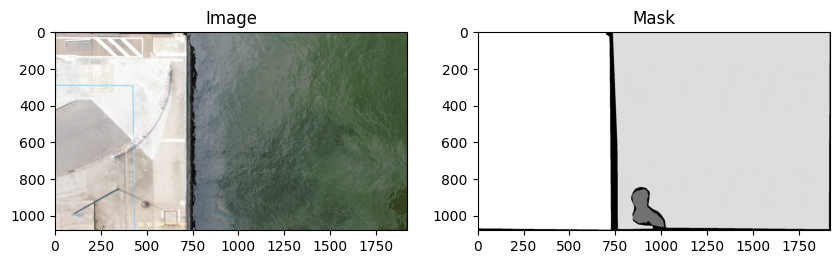

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Pick first pair
img_path = train_img_paths[0]
mask_path = train_mask_paths[0]

print("Image:", img_path)
print("Mask:", mask_path)

# Read
image = cv2.imread(img_path)
mask = cv2.imread(mask_path, 0)  # grayscale

# Plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.show()


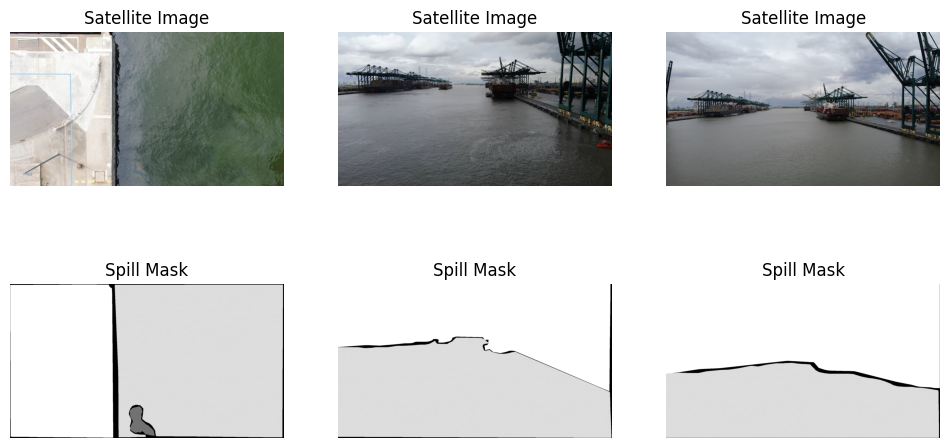

In [ ]:
# ----------------------------
# 2. Visualize sample images + masks
# ----------------------------
def show_samples(img_paths, mask_paths, n=3):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        img = cv2.imread(img_paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)

        plt.subplot(2, n, i+1)
        plt.imshow(img)
        plt.title("Satellite Image")
        plt.axis("off")

        plt.subplot(2, n, i+1+n)
        plt.imshow(mask, cmap="gray")
        plt.title("Spill Mask")
        plt.axis("off")
    plt.show()

show_samples(train_img_paths, train_mask_paths, n=3)

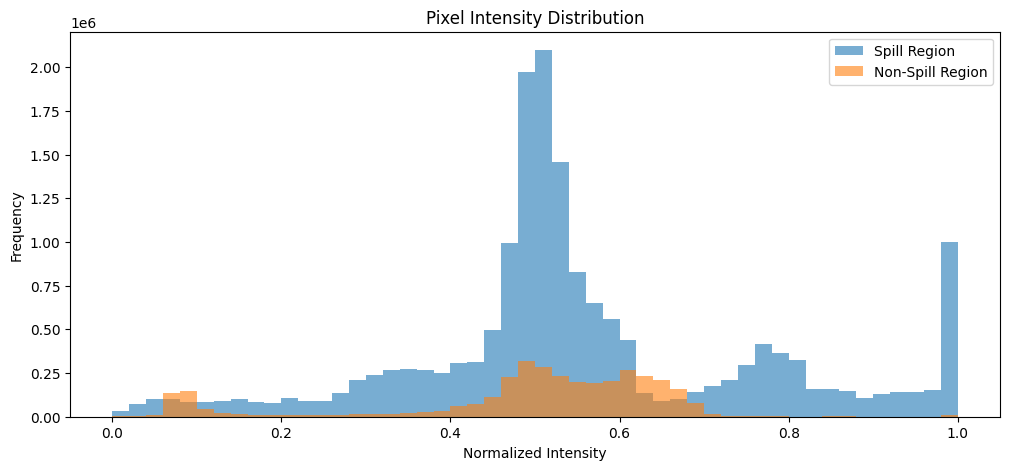

'\nYou’ll see two distributions:\n\nSpill region intensity distribution.\n\nNon-spill region intensity distribution.\n\nIf they are separated, it means the model can easily learn to distinguish oil spills based on pixel brightness.\n\nIf they overlap heavily, then you’ll need more advanced features (texture, context, deep CNN) for segmentation.'

In [ ]:
# ----------------------------
# 3. Statistical properties
# ----------------------------
def analyze_statistics(img_paths, mask_paths, n=10):
    spill_pixels, nonspill_pixels = [], []

    for i in range(min(n, len(img_paths))):
        img = cv2.imread(img_paths[i], cv2.IMREAD_GRAYSCALE) / 255.0
        mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8)

        spill_pixels.extend(img[mask == 1].flatten())
        nonspill_pixels.extend(img[mask == 0].flatten())

    plt.figure(figsize=(12, 5))
    plt.hist(spill_pixels, bins=50, alpha=0.6, label="Spill Region")
    plt.hist(nonspill_pixels, bins=50, alpha=0.6, label="Non-Spill Region")
    plt.title("Pixel Intensity Distribution")
    plt.xlabel("Normalized Intensity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

analyze_statistics(train_img_paths, train_mask_paths)

'''
You’ll see two distributions:

Spill region intensity distribution.

Non-spill region intensity distribution.

If they are separated, it means the model can easily learn to distinguish oil spills based on pixel brightness.

If they overlap heavily, then you’ll need more advanced features (texture, context, deep CNN) for segmentation.'''


In [ ]:
# ----------------------------
# 4. Preprocessing setup
# ----------------------------
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
BUFFER_SIZE = 512
AUTOTUNE = tf.data.AUTOTUNE

# Median filter for speckle noise reduction
def apply_median_filter(img):
    img = img.numpy()
    img = cv2.medianBlur((img*255).astype(np.uint8), 3) #median filter 3x3 median filter is applied..that noised pixel is replaced by the neighbourhood median.
    img = img.astype(np.float32) / 255.0
    return img

def parse_image_mask(img_path, mask_path):
    # Load and decode
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.convert_image_dtype(mask, tf.float32)
    mask = tf.where(mask > 0.5, 1.0, 0.0)  # binarize

    # Resize
    img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
    mask = tf.image.resize(mask, IMG_SIZE, method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    # Apply SAR noise reduction
    img = tf.py_function(apply_median_filter, [img], tf.float32)

    # Restore shape
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    mask.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])

    return img, mask

In [ ]:
# ----------------------------
# 5. Data augmentation
# ----------------------------
def augment_image_mask(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)

    scale = tf.random.uniform([], 0.9, 1.1)
    new_size = (int(IMG_SIZE[0]*scale), int(IMG_SIZE[1]*scale))
    img = tf.image.resize(img, new_size)
    mask = tf.image.resize(mask, new_size, method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    mask = tf.image.resize_with_crop_or_pad(mask, IMG_SIZE[0], IMG_SIZE[1])

    return img, mask

In [ ]:
# ----------------------------
# 6. Dataset builder
# ----------------------------
def prepare_dataset(img_paths, mask_paths, training=False):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if training:
        ds = ds.shuffle(BUFFER_SIZE, reshuffle_each_iteration=True)
    ds = ds.map(parse_image_mask, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment_image_mask, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_dataset = prepare_dataset(train_img_paths, train_mask_paths, training=True)
val_dataset   = prepare_dataset(val_img_paths, val_mask_paths, training=False)
test_dataset  = prepare_dataset(test_img_paths, test_mask_paths, training=False)


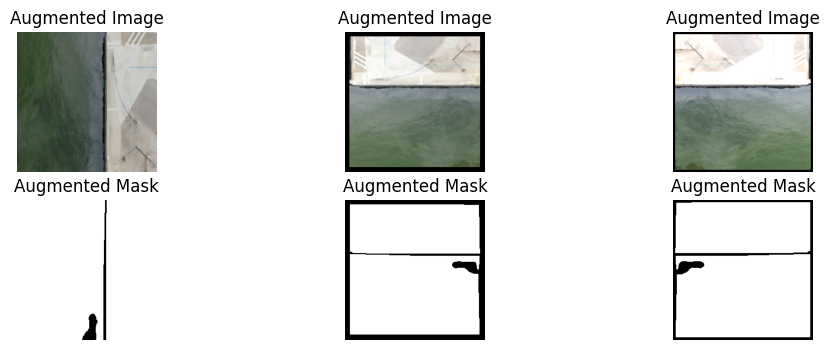

In [ ]:
# ----------------------------
# 7. Test visualization of augmentations
# ----------------------------
def show_augmentations(img_path, mask_path, n=3):
    img, mask = parse_image_mask(img_path, mask_path)
    plt.figure(figsize=(12, 4))
    for i in range(n):
        aug_img, aug_mask = augment_image_mask(img, mask)
        plt.subplot(2, n, i+1)
        plt.imshow(aug_img.numpy())
        plt.axis("off")
        plt.title("Augmented Image")

        plt.subplot(2, n, i+1+n)
        plt.imshow(aug_mask.numpy().squeeze(), cmap="gray")
        plt.axis("off")
        plt.title("Augmented Mask")
    plt.show()

show_augmentations(train_img_paths[0], train_mask_paths[0])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K

In [ ]:
# ---------------------------
# Helper blocks
# ---------------------------
def conv_block(x, filters, kernel_size=3, activation="relu", batchnorm=True):
    x = layers.Conv2D(filters, kernel_size, padding="same", kernel_initializer="he_normal")(x)
    if batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)

    x = layers.Conv2D(filters, kernel_size, padding="same", kernel_initializer="he_normal")(x)
    if batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def encoder_block(x, filters, pool_size=(2,2), dropout=0.0):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D(pool_size)(c)
    if dropout and dropout > 0:
        p = layers.Dropout(dropout)(p)
    return c, p

def decoder_block(x, skip, filters, kernel_size=3, strides=(2,2)):
    # Use Conv2DTranspose for learned upsampling (alternatively UpSampling2D + Conv)
    x = layers.Conv2DTranspose(filters, kernel_size, strides=strides, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

In [ ]:
# ---------------------------
# U-Net builder
# ---------------------------
def build_unet(input_shape=(256,256,3), base_filters=32, dropout=0.1):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1, p1 = encoder_block(inputs, base_filters)
    c2, p2 = encoder_block(p1, base_filters*2)
    c3, p3 = encoder_block(p2, base_filters*4)
    c4, p4 = encoder_block(p3, base_filters*8)

    # Bottleneck
    bn = conv_block(p4, base_filters*16)
    bn = layers.Dropout(dropout*2)(bn)

    # Decoder
    d4 = decoder_block(bn, c4, base_filters*8)
    d3 = decoder_block(d4, c3, base_filters*4)
    d2 = decoder_block(d3, c2, base_filters*2)
    d1 = decoder_block(d2, c1, base_filters)

    # Output
    outputs = layers.Conv2D(1, (1,1), padding="same", activation="sigmoid")(d1)

    model = Model(inputs, outputs, name="U-Net")
    return model

In [ ]:
# ---------------------------
# Losses & metrics
# ---------------------------
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = K.cast(y_pred > 0.5, 'float32')
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [ ]:
# ---------------------------
# Build & compile
# ---------------------------
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)  # from your preprocessing
model = build_unet(input_shape=input_shape, base_filters=32, dropout=0.1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=bce_dice_loss,
              metrics=[dice_coef, iou_metric, "accuracy"])

model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_36[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ activation_37[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_38[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ activation_39[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_42[0][0] 

 Total params: 8,642,273 (32.97 MB)

 Trainable params: 8,636,385 (32.95 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
# ---------------------------
# Callbacks (recommended)
# ---------------------------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("unet_oilspil.h5", save_best_only=True, monitor="val_iou_metric", mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_iou_metric", patience=12, restore_best_weights=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_iou_metric", factor=0.5, patience=4, min_lr=1e-7, mode="max")
]


In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K  # use tf.keras consistently

# Dice coefficient metric
@tf.keras.utils.register_keras_serializable(package="Custom")
def dice_coef(y_true, y_pred, smooth=1e-6):
    # Flatten both tensors
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    # Compute intersection and Dice coefficient
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


# IoU metric
@tf.keras.utils.register_keras_serializable(package="Custom")
def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)


# Dice loss (1 - Dice coefficient)
@tf.keras.utils.register_keras_serializable(package="Custom")
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


# Combined Binary Crossentropy + Dice loss
@tf.keras.utils.register_keras_serializable(package="Custom")
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


In [ ]:
import os

def save_model(model):
    base_path = "/content/drive/MyDrive/OilSpillModels"

    # Save in new native Keras format (recommended)
    keras_path = os.path.join(base_path, "final_unet_oilspill.keras")
    model.save(keras_path)
    print(f"✅ Model saved in native Keras format: {keras_path}")

    # Save in HDF5 format for backward compatibility
    h5_path = os.path.join(base_path, "final_unet_oilspill.h5")
    model.save(h5_path)
    print(f"✅ Model saved in HDF5 format: {h5_path}")

    # Save in TensorFlow SavedModel format (for TFLite, TFServing, etc.)
    tf_path = os.path.join(base_path, "final_unet_oilspill_savedmodel")
    model.export(tf_path)
    print(f"✅ Model exported in TensorFlow SavedModel format: {tf_path}")


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model

def load_saved_model():
    choice = input("Enter model type to load (H5 / TF / Keras): ").strip().lower()
    base_path = "/content/drive/MyDrive/OilSpillModels"

    keras_path = os.path.join(base_path, "final_unet_oilspill.keras")
    h5_path = os.path.join(base_path, "final_unet_oilspill.h5")
    tf_path = os.path.join(base_path, "final_unet_oilspill_savedmodel")

    # Custom objects for model loading
    custom_objects = {
        "dice_coef": dice_coef,
        "iou_metric": iou_metric,
        "dice_loss": dice_loss,
        "bce_dice_loss": bce_dice_loss
    }

    if choice == 'h5':
        model = load_model(h5_path, custom_objects=custom_objects, compile=False)
        model.compile(optimizer='adam',
                      loss=bce_dice_loss,
                      metrics=[dice_coef, iou_metric, 'accuracy'])

    elif choice == 'keras':
        model = load_model(keras_path, custom_objects=custom_objects, compile=False)
        model.compile(optimizer='adam',
                      loss=bce_dice_loss,
                      metrics=[dice_coef, iou_metric, 'accuracy'])

    elif choice == 'tf':
        # Keras 3 no longer supports SavedModel directly
        print("⚠️ Keras 3 does not support loading TensorFlow SavedModel via load_model().")
        print("Loading as inference-only model using TFSMLayer...")
        model = tf.keras.Sequential([
            tf.keras.layers.TFSMLayer(tf_path, call_endpoint='serving_default')
        ])
        print("✅ Loaded TensorFlow SavedModel for inference only (no training).")

    else:
        raise ValueError("Invalid choice. Please enter 'H5', 'TF', or 'Keras'.")

    print(f"✅ Model loaded successfully from: {choice.upper()}")
    return model


In [ ]:
while True:
    choice = input("Enter Y to retrain model, N to reuse last saved model: ").strip().upper()

    if choice == 'Y':
        print("Retraining model...")
        EPOCHS = 30
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=EPOCHS,
            callbacks=callbacks
        )
        model.summary()

        # After training, evaluate on test set:
        test_results = model.evaluate(test_dataset)
        print("Test results (loss, dice, iou, acc):", test_results)

        save_model(model)
        break

    elif choice == 'N':
        print("Reusing last saved model...")
        model = load_saved_model()
        model.summary()
        break

    else:
        print("Invalid input. Please enter only 'Y' or 'N'.")

Enter Y to retrain model, N to reuse last saved model: Y
Retraining model...
Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.6477 - dice_coef: 0.5931 - iou_metric: 0.4522 - loss: 1.0331

102/102 ━━━━━━━━━━━━━━━━━━━━ 110s 816ms/step - accuracy: 0.6485 - dice_coef: 0.5938 - iou_metric: 0.4535 - loss: 1.0315 - val_accuracy: 0.4939 - val_dice_coef: 0.3902 - val_iou_metric: 0.1534 - val_loss: 1.6180 - learning_rate: 1.0000e-04
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8176 - dice_coef: 0.7628 - iou_metric: 0.7273 - loss: 0.6639

102/102 ━━━━━━━━━━━━━━━━━━━━ 63s 616ms/step - accuracy: 0.8177 - dice_coef: 0.7630 - iou_metric: 0.7274 - loss: 0.6636 - val_accuracy: 0.7056 - val_dice_coef: 0.6021 - val_iou_metric: 0.5304 - val_loss: 1.0340 - learning_rate: 1.0000e-04
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.8333 - dice_coef: 0.7898 - iou_metric: 0.7530 - loss: 0.5959

102/102 ━━━━━━━━━━━━━━━━━━━━ 62s 611ms/step - accuracy: 0.8333 - dice_coef: 0.7899 - iou_metric: 0.7532 - loss: 0.5956 - val_accuracy: 0.7686 - val_dice_coef: 0.7083 - val_iou_metric: 0.6530 - val_loss: 0.7877 - learning_rate: 1.0000e-04
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.8320 - dice_coef: 0.7959 - iou_metric: 0.7497 - loss: 0.5919

102/102 ━━━━━━━━━━━━━━━━━━━━ 65s 636ms/step - accuracy: 0.8321 - dice_coef: 0.7960 - iou_metric: 0.7498 - loss: 0.5916 - val_accuracy: 0.8581 - val_dice_coef: 0.7789 - val_iou_metric: 0.7544 - val_loss: 0.5511 - learning_rate: 1.0000e-04
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.8423 - dice_coef: 0.8133 - iou_metric: 0.7674 - loss: 0.5415

...

 Trainable params: 8,636,385 (32.95 MB)

 Non-trainable params: 5,888 (23.00 KB)

 Optimizer params: 17,272,772 (65.89 MB)

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 441ms/step - accuracy: 0.9382 - dice_coef: 0.8994 - iou_metric: 0.8911 - loss: 0.2731
Test results (loss, dice, iou, acc): [0.3020819425582886, 0.8800785541534424, 0.8604260683059692, 0.929577648639679]


✅ Model saved in native Keras format: /content/drive/MyDrive/OilSpillModels/final_unet_oilspill.keras
✅ Model saved in HDF5 format: /content/drive/MyDrive/OilSpillModels/final_unet_oilspill.h5
Saved artifact at '/content/drive/MyDrive/OilSpillModels/final_unet_oilspill_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_138')
Output Type:
  TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)
Captures:
  139579032244432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139579032241936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139579032242704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139579032255376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139579032246160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139579032249616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139579032240592: TensorSpec(shape=(

In [ ]:
# Use trained model, evaluate on validation set:
val_results = model.evaluate(val_dataset)
print("Test results on validation dataset (loss, dice, iou, acc):", val_results)

26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 686ms/step - accuracy: 0.9423 - dice_coef: 0.8985 - iou_metric: 0.8972 - loss: 0.2715
Test results on validation dataset (loss, dice, iou, acc): [0.2374492883682251, 0.9069359302520752, 0.910173773765564, 0.9525120258331299]


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


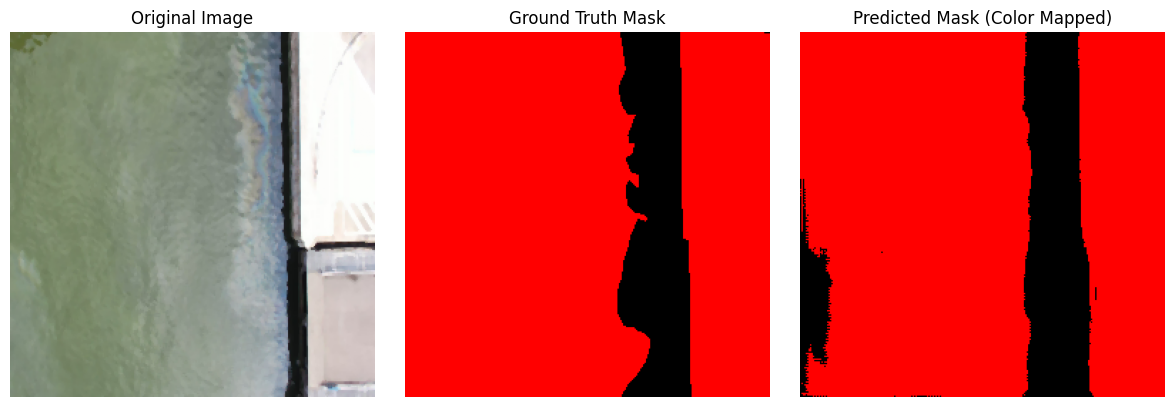

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


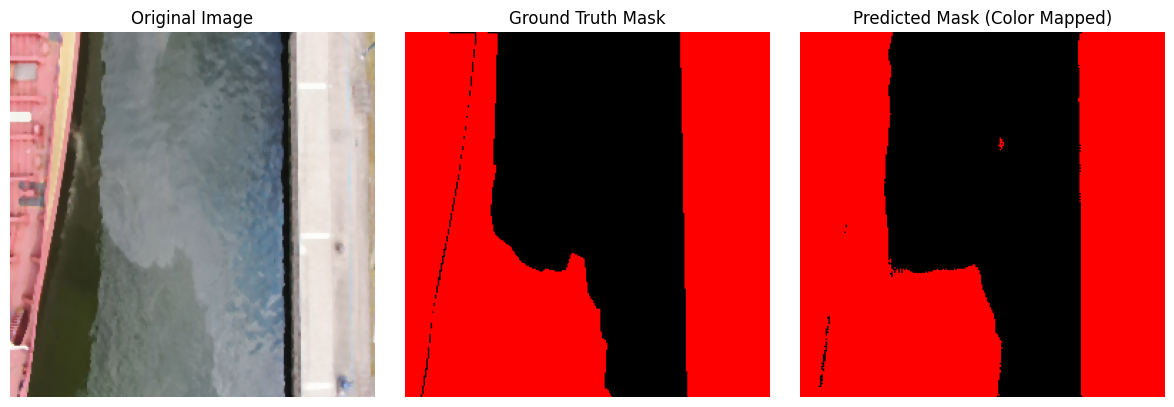

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


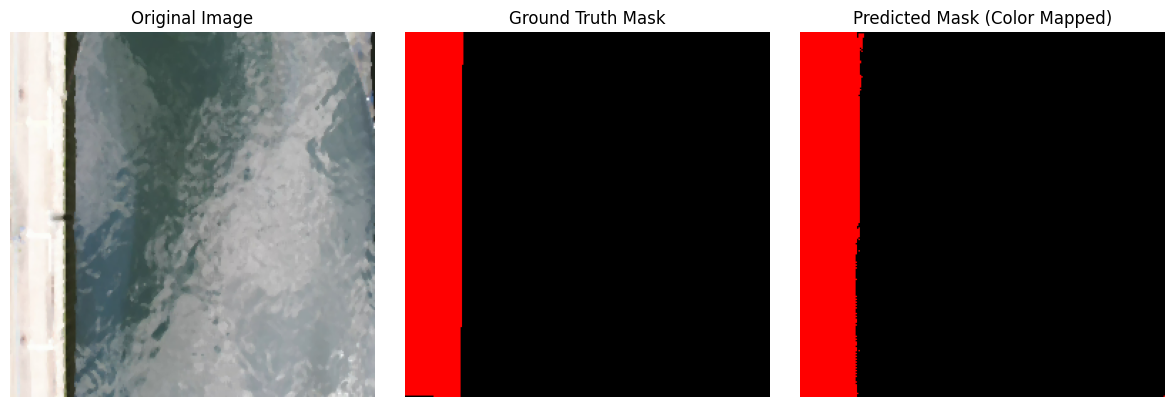

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# ---------------------------
# Color Mapping Visualization
# ---------------------------

for imgs, masks in val_dataset.take(3):  # or test_dataset if available
    preds = model.predict(imgs)

    # Convert predictions to binary masks (0 or 1)
    preds_binary = (preds > 0.5).astype(np.uint8)

    # Create a simple color map: 0=black (background), 1=red (oil spill)
    cmap = ListedColormap(["black", "red"])

    i = 0  # index of image in the batch
    plt.figure(figsize=(12, 4))

    # Original input image
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(imgs[i].numpy())
    plt.axis("off")

    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask")
    plt.imshow(masks[i].numpy().squeeze(), cmap=cmap)
    plt.axis("off")

    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask (Color Mapped)")
    plt.imshow(preds_binary[i].squeeze(), cmap=cmap)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


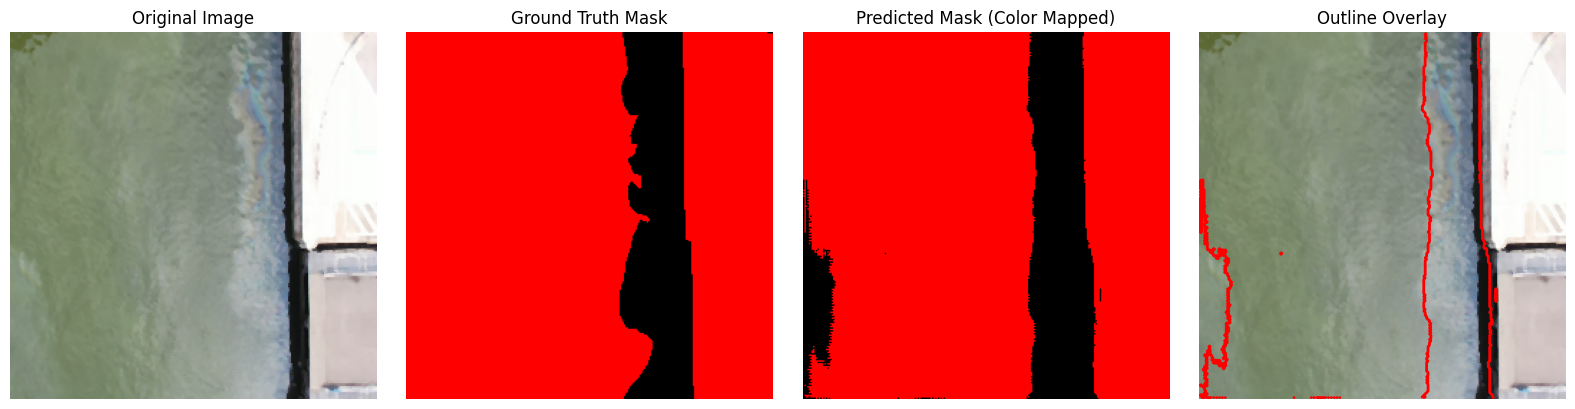

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


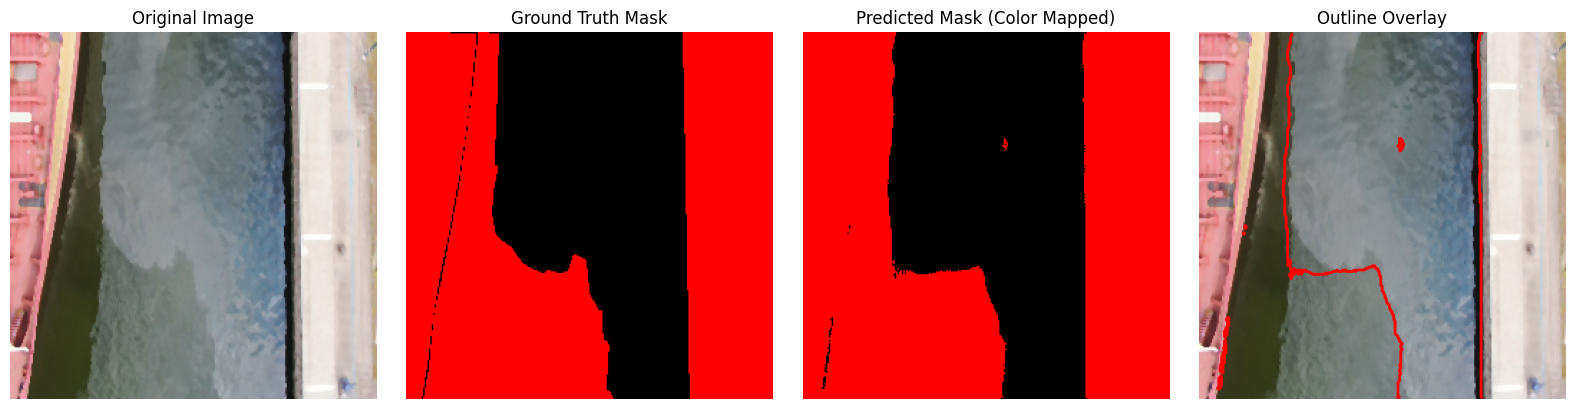

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


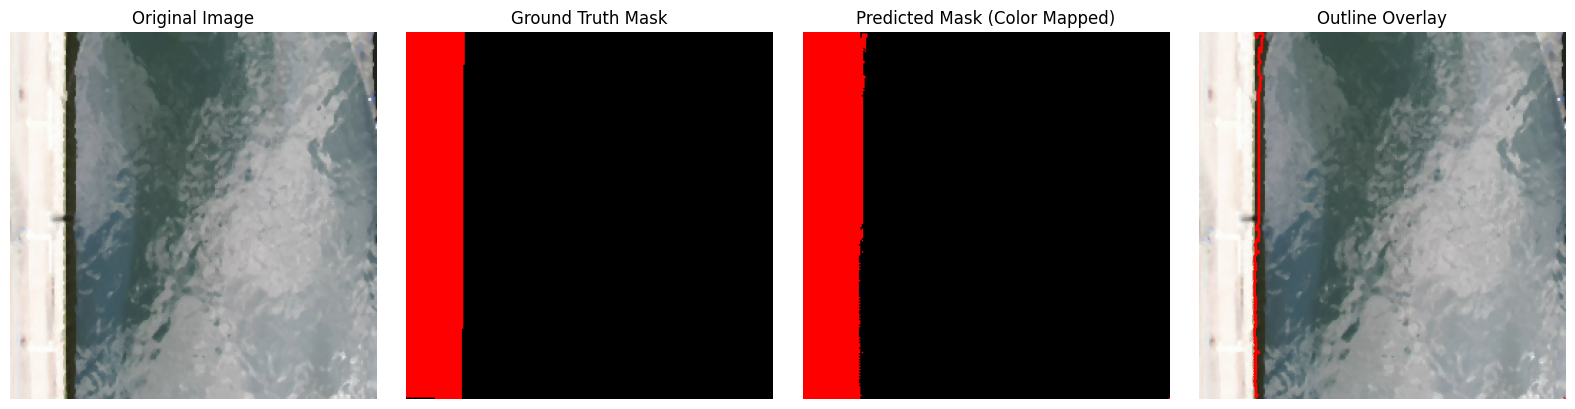

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


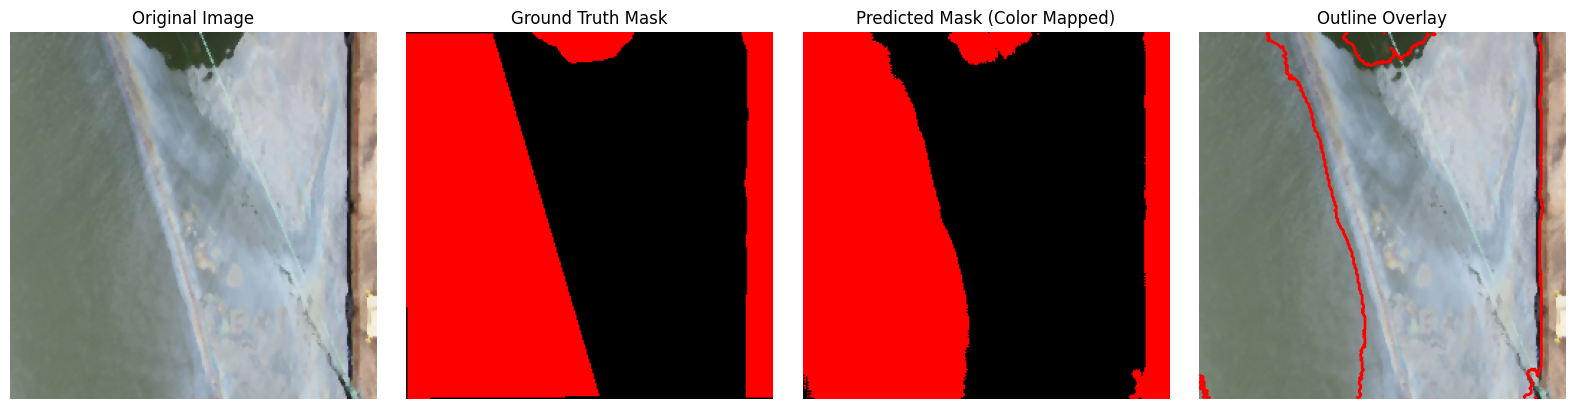

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


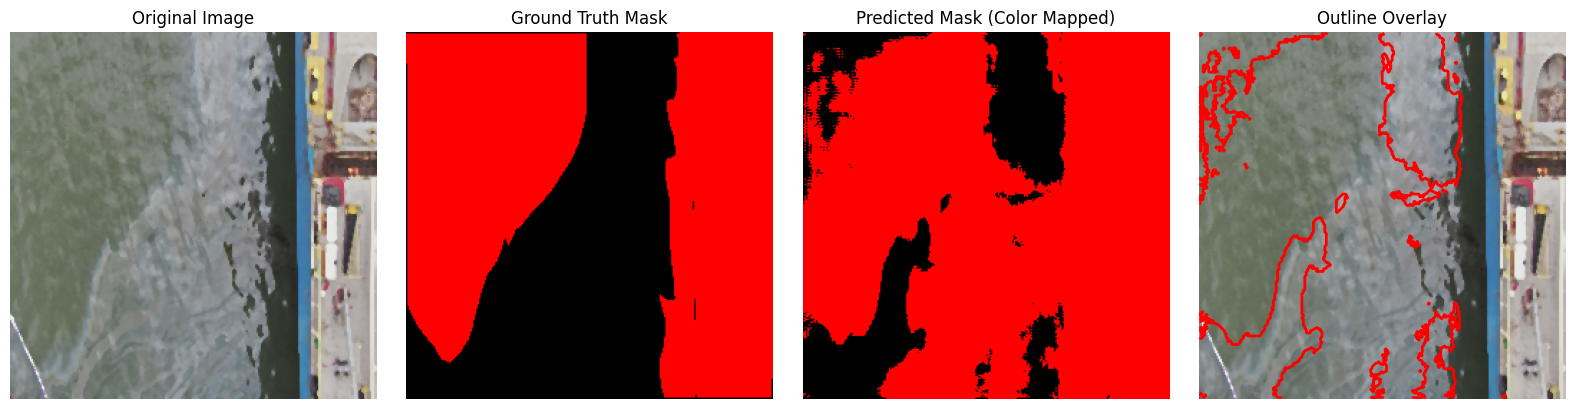

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


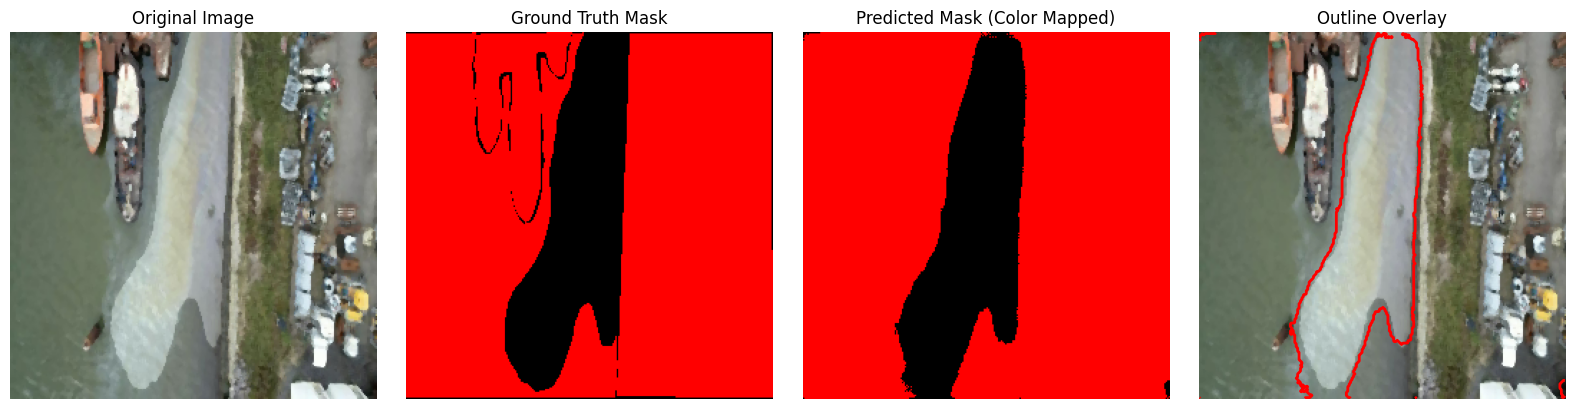

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


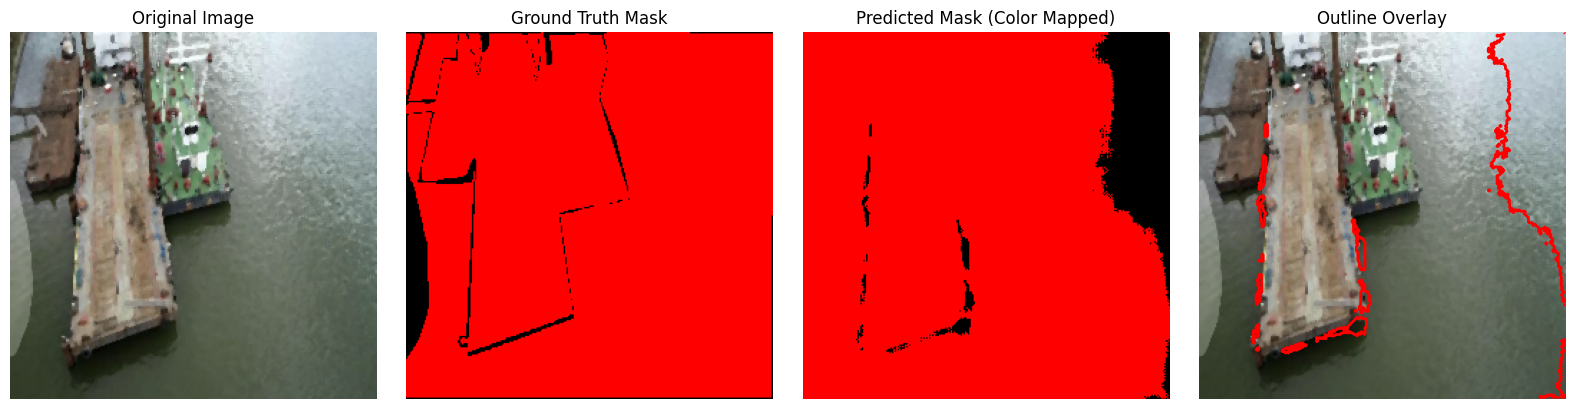

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


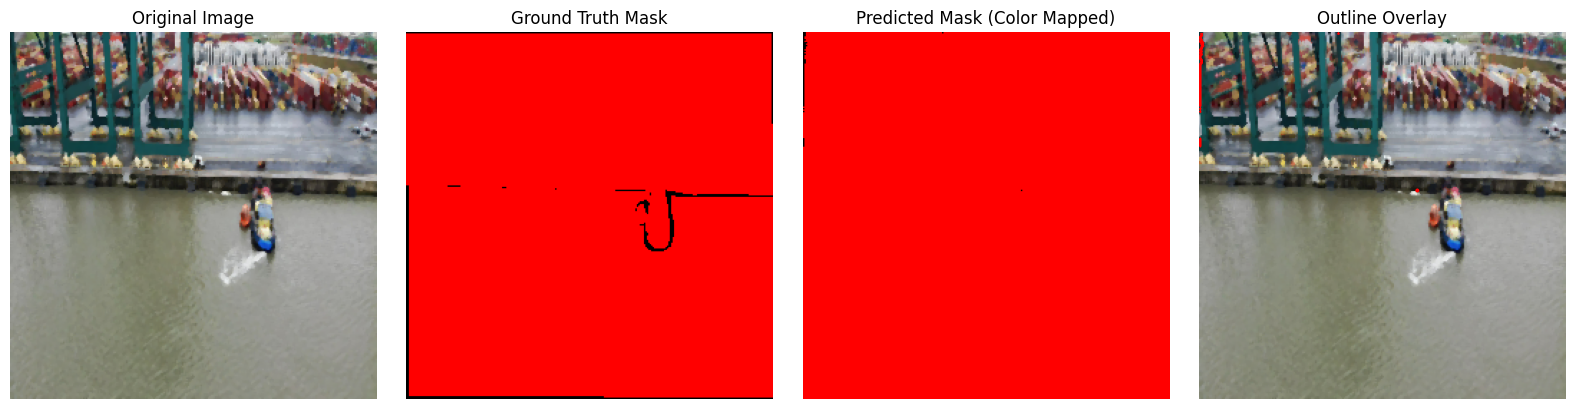

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


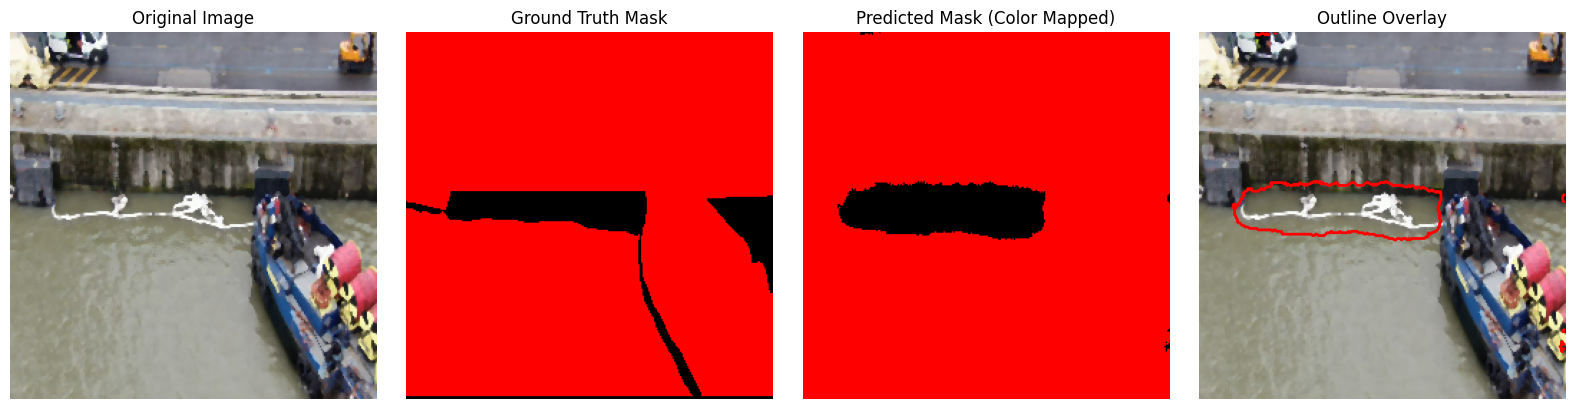

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


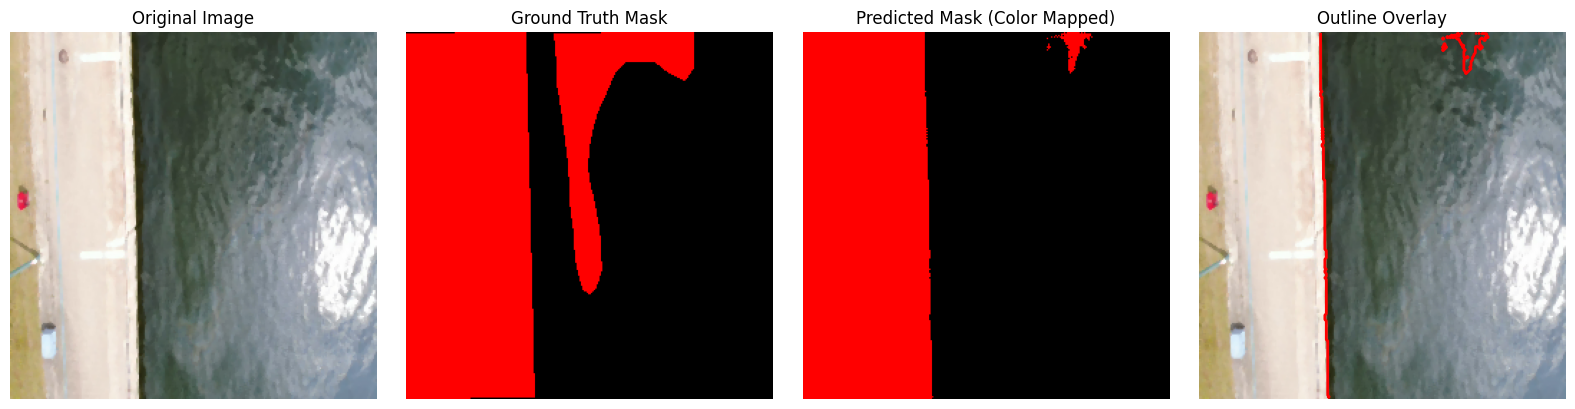

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# ---------------------------
# Color Mapping Visualization + Outline Overlay
# ---------------------------

for imgs, masks in val_dataset.take(10):  # or test_dataset if available
    preds = model.predict(imgs)

    # Convert predictions to binary masks (0 or 1)
    preds_binary = (preds > 0.5).astype(np.uint8)

    # Create color map: 0=black (background), 1=red (oil spill)
    cmap = ListedColormap(["black", "red"])

    i = 0  # index of image in the batch
    plt.figure(figsize=(16, 4))

    # ---------------------------
    # 1️⃣ Original input image
    # ---------------------------
    plt.subplot(1, 4, 1)
    plt.title("Original Image")
    plt.imshow(imgs[i].numpy())
    plt.axis("off")

    # ---------------------------
    # 2️⃣ Ground truth mask
    # ---------------------------
    plt.subplot(1, 4, 2)
    plt.title("Ground Truth Mask")
    plt.imshow(masks[i].numpy().squeeze(), cmap=cmap)
    plt.axis("off")

    # ---------------------------
    # 3️⃣ Predicted mask (color mapped)
    # ---------------------------
    plt.subplot(1, 4, 3)
    plt.title("Predicted Mask (Color Mapped)")
    plt.imshow(preds_binary[i].squeeze(), cmap=cmap)
    plt.axis("off")

    # ---------------------------
    # 4️⃣ Original image + outline of oil spill
    # ---------------------------
    plt.subplot(1, 4, 4)
    plt.title("Outline Overlay")
    plt.imshow(imgs[i].numpy())
    plt.axis("off")

    # Add outline (contour) in red
    plt.contour(
        preds_binary[i].squeeze(),
        levels=[0.5],
        colors="red",
        linewidths=2
    )

    plt.tight_layout()
    plt.show()


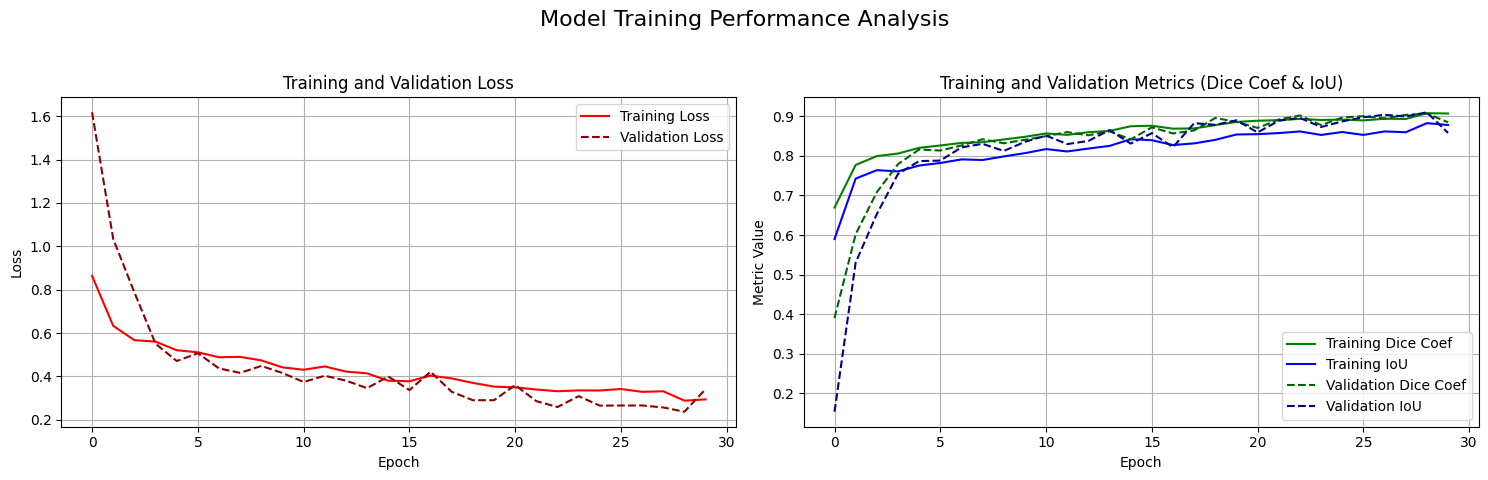

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_training_history(history):
    """
    Plots the training and validation loss and metrics (Dice Coef and IoU) over epochs.

    Args:
        history (tf.keras.callbacks.History): The history object returned by model.fit().
    """
    # Convert history dict to DataFrame for easier plotting
    hist_df = pd.DataFrame(history.history)

    plt.figure(figsize=(15, 5))

    # --- Plot 1: Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(hist_df['loss'], label='Training Loss', color='red')
    # Check for validation data before plotting
    if 'val_loss' in hist_df.columns:
        plt.plot(hist_df['val_loss'], label='Validation Loss', color='darkred', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # --- Plot 2: Metrics (Dice Coef and IoU) ---
    plt.subplot(1, 2, 2)
    plt.plot(hist_df['dice_coef'], label='Training Dice Coef', color='green')
    plt.plot(hist_df['iou_metric'], label='Training IoU', color='blue')
    # Check for validation data before plotting
    if 'val_dice_coef' in hist_df.columns:
        plt.plot(hist_df['val_dice_coef'], label='Validation Dice Coef', color='darkgreen', linestyle='--')
    if 'val_iou_metric' in hist_df.columns:
        plt.plot(hist_df['val_iou_metric'], label='Validation IoU', color='darkblue', linestyle='--')

    plt.title('Training and Validation Metrics (Dice Coef & IoU)')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)

    plt.suptitle('Model Training Performance Analysis', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- How to use it in your notebook ---
# Assuming 'history' is the result of model.fit():
plot_training_history(history)

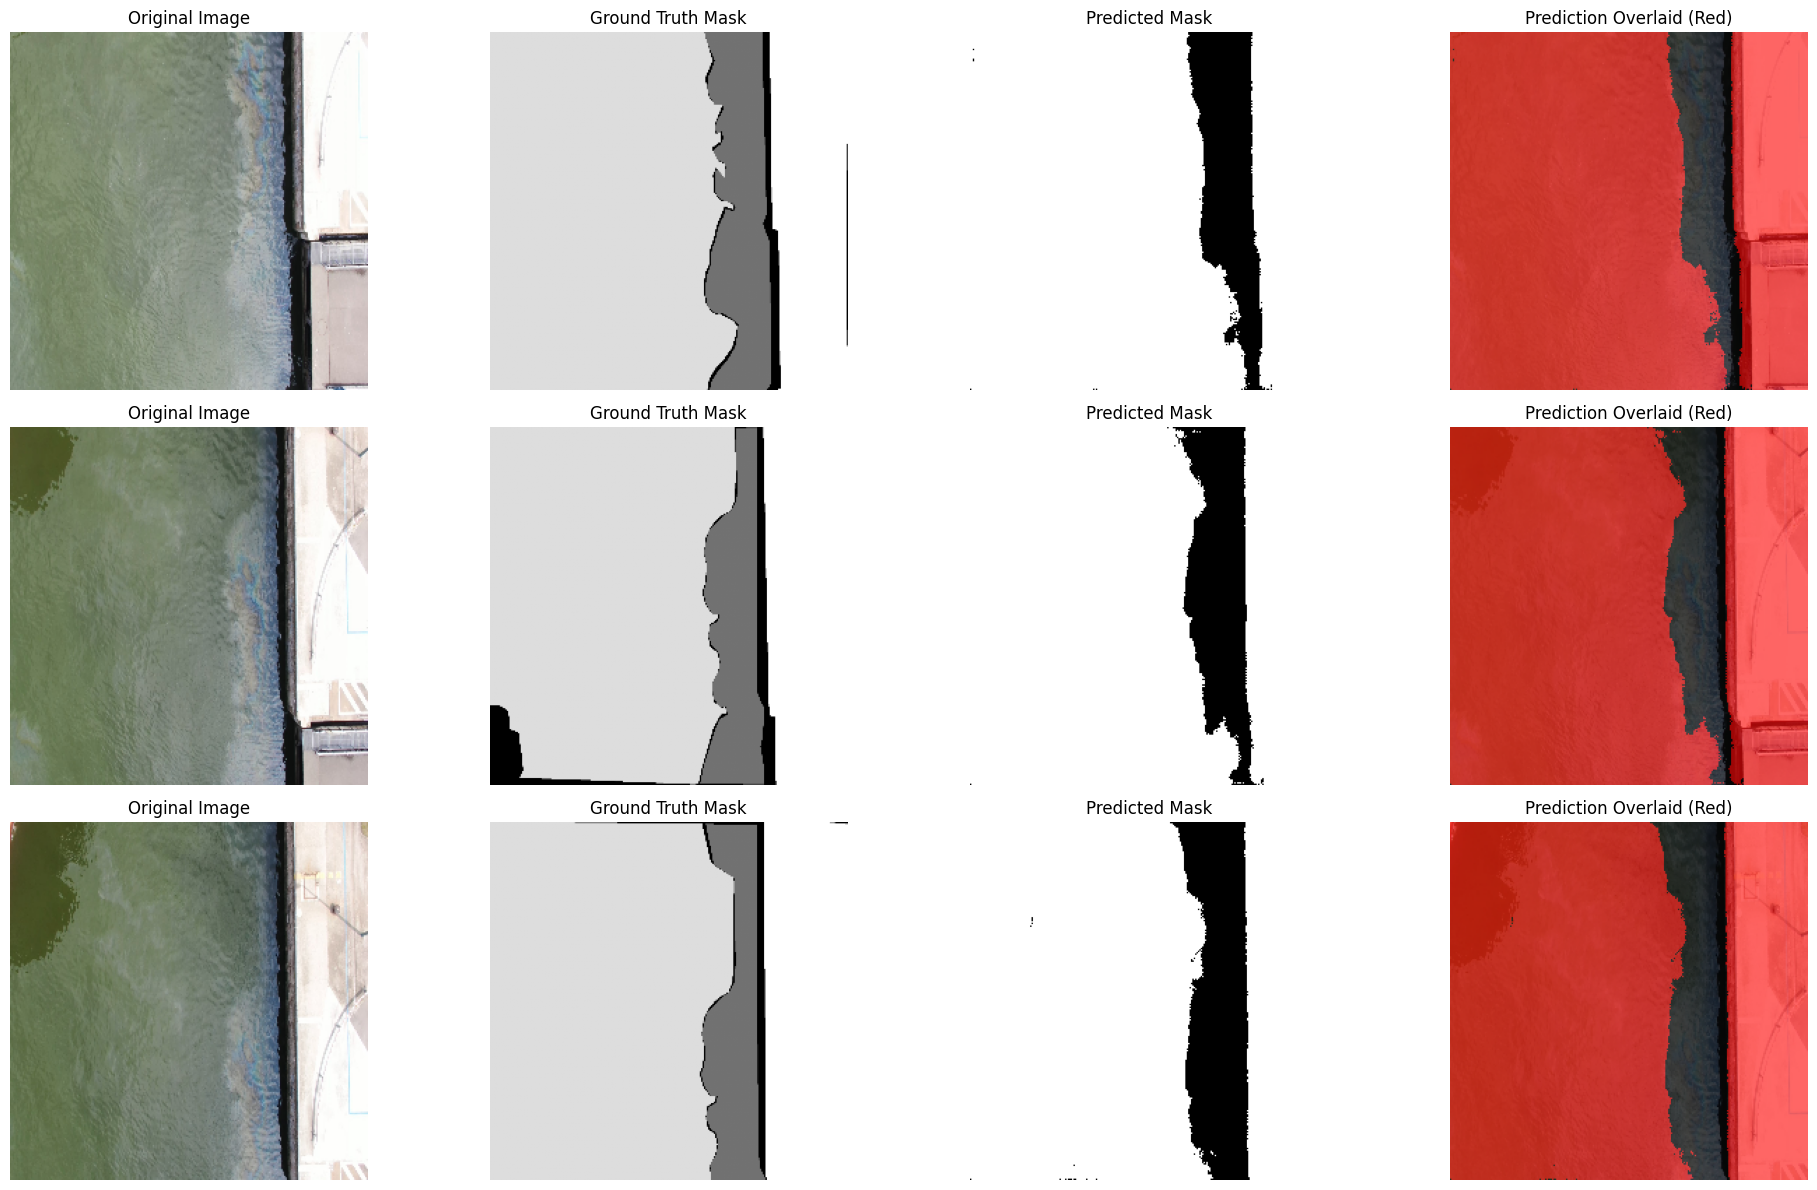

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
# Assuming IMG_SIZE is defined (e.g., IMG_SIZE = 256)
# Assuming read_image and read_mask are defined as in your notebook (for preprocessing)
# Example definitions of dependencies for a standalone block:
IMG_SIZE = 256

def read_image(path):
    # Loads, converts to RGB, resizes, and normalizes the image for model input (0-1)
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img.astype(np.float32)

def read_mask(path):
    # Loads, resizes, adds a channel dimension, and normalizes the mask (0 or 1)
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = np.expand_dims(mask, axis=-1)
    mask = mask / 255.0
    return mask.astype(np.float32)

def overlay_mask(image, mask, alpha=0.5, color=(255, 0, 0)):
    """
    Overlays a segmentation mask onto an original image using a color map.

    Args:
        image (np.ndarray): The original input image (H, W, 3), typically 0-255.
        mask (np.ndarray): The binary mask (H, W) or (H, W, 1).
        alpha (float): Transparency level of the mask (0.0 to 1.0).
        color (tuple): RGB color of the mask (e.g., Red for the spill).

    Returns:
        np.ndarray: The overlaid image.
    """
    h, w, _ = image.shape
    # Create a blank, colored overlay
    mask_colored = np.zeros((h, w, 3), dtype=np.uint8)

    # Convert mask to binary indices
    mask_indices = mask > 0.5
    if mask_indices.ndim == 3:
      mask_indices = mask_indices[:,:,0]

    # Color the spill pixels
    mask_colored[mask_indices] = color

    # Blend the original image and the colored mask
    overlaid = cv2.addWeighted(image, 1 - alpha, mask_colored, alpha, 0)
    return overlaid

def display_results(model, test_img_paths, test_mask_paths, num_samples=5):
    """
    Generates and displays side-by-side comparisons:
    Original Image, Ground Truth Mask, Predicted Mask, and Overlaid Prediction.

    Args:
        model: The trained segmentation model.
        test_img_paths (list): File paths for test images.
        test_mask_paths (list): File paths for test masks.
        num_samples (int): Number of test samples to display.
    """
    plt.figure(figsize=(20, 4 * num_samples)) # Set figure size for clarity

    for i in range(num_samples):
        # --- 1. Load and Preprocess Data ---
        img_path = test_img_paths[i]
        mask_path = test_mask_paths[i]

        # Read the image and mask using the defined helper functions
        input_img = read_image(img_path)
        input_mask_gt = read_mask(mask_path)
        input_mask_gt = np.squeeze(input_mask_gt) # (H, W) for plotting

        # Prepare image for prediction (add batch dimension)
        input_for_pred = np.expand_dims(input_img, axis=0)


        # --- 2. Prediction ---
        predicted_mask_raw = model.predict(input_for_pred, verbose=0)[0]

        # Convert raw prediction to a binary mask (0 or 1)
        predicted_mask_binary = (predicted_mask_raw > 0.5).astype(np.uint8)
        predicted_mask_binary = np.squeeze(predicted_mask_binary) # (H, W) for plotting

        # --- 3. Prepare Images for Visualization (Scale to 0-255) ---
        # The original image needs to be scaled back to 0-255 for proper overlay with cv2
        original_img_255 = (input_img * 255).astype(np.uint8)

        # Create the overlaid image: Prediction Mask (Red) overlaid on Original Image
        overlaid_pred = overlay_mask(
            original_img_255,
            predicted_mask_binary,
            alpha=0.6,
            color=(255, 0, 0) # Red color for the predicted spill
        )

        # --- 4. Plotting (Side-by-Side Comparison) ---
        # Plotting 4 columns: Original, Ground Truth Mask, Predicted Mask, Overlaid Result
        row = i + 1

        # Col 1: Original Image
        plt.subplot(num_samples, 4, (row * 4) - 3)
        plt.imshow(original_img_255)
        plt.title('Original Image')
        plt.axis('off')

        # Col 2: Ground Truth Mask
        plt.subplot(num_samples, 4, (row * 4) - 2)
        # Use a colormap ('gray') to visualize the binary mask
        plt.imshow(input_mask_gt, cmap='gray')
        plt.title('Ground Truth Mask')
        plt.axis('off')

        # Col 3: Predicted Mask
        plt.subplot(num_samples, 4, (row * 4) - 1)
        # Use a colormap ('gray') to visualize the predicted binary mask
        plt.imshow(predicted_mask_binary, cmap='gray')
        plt.title('Predicted Mask')
        plt.axis('off')

        # Col 4: Predicted Mask Overlaid
        plt.subplot(num_samples, 4, (row * 4))
        plt.imshow(overlaid_pred)
        plt.title('Prediction Overlaid (Red)')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Example Execution (requires a trained model) ---
display_results(model, test_img_paths, test_mask_paths, num_samples=3)

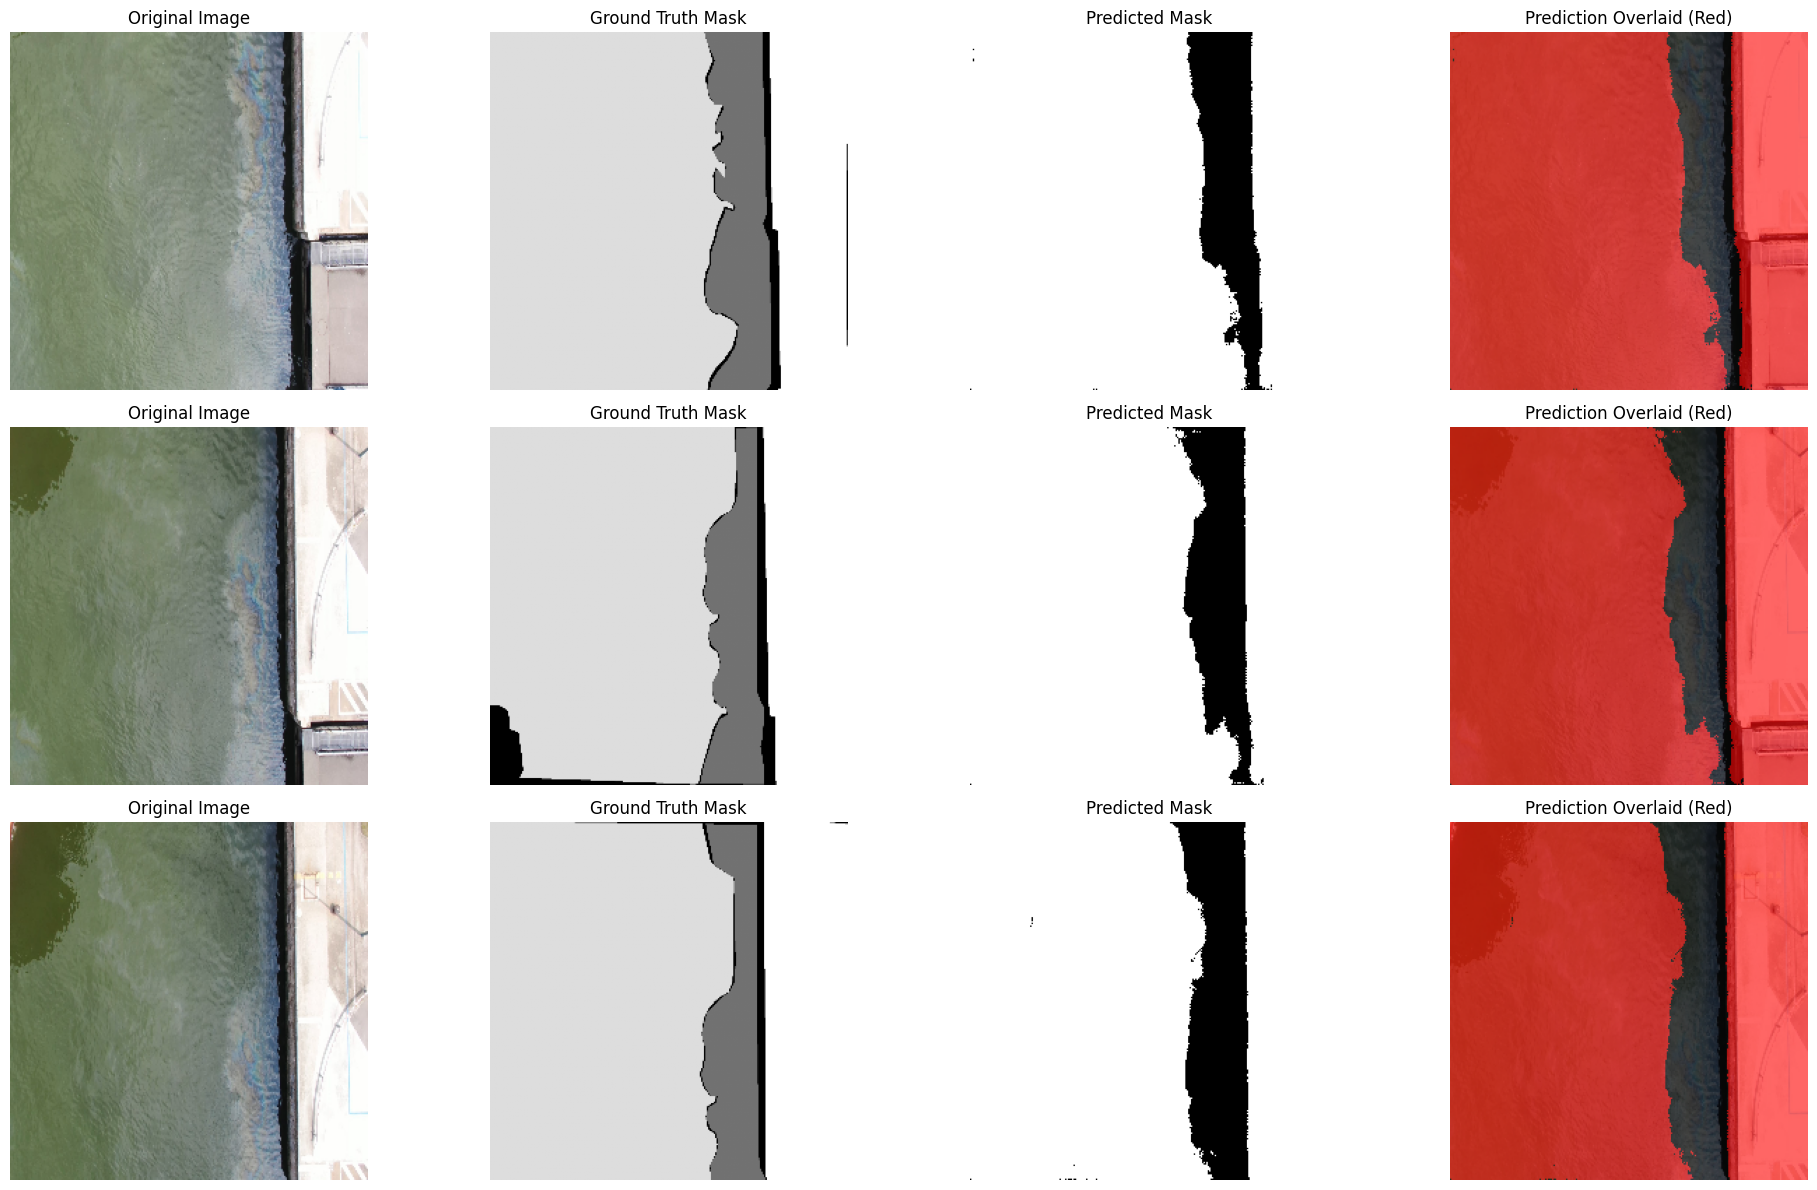

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
# Assuming IMG_SIZE is defined (e.g., IMG_SIZE = 256)
# Assuming read_image and read_mask are defined as in your notebook (for preprocessing)
# Example definitions of dependencies for a standalone block:
IMG_SIZE = 256

def read_image(path):
    # Loads, converts to RGB, resizes, and normalizes the image for model input (0-1)
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img.astype(np.float32)

def read_mask(path):
    # Loads, resizes, adds a channel dimension, and normalizes the mask (0 or 1)
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = np.expand_dims(mask, axis=-1)
    mask = mask / 255.0
    return mask.astype(np.float32)

def overlay_mask(image, mask, alpha=0.5, color=(255, 0, 0)):
    """
    Overlays a segmentation mask onto an original image using a color map.

    Args:
        image (np.ndarray): The original input image (H, W, 3), typically 0-255.
        mask (np.ndarray): The binary mask (H, W) or (H, W, 1).
        alpha (float): Transparency level of the mask (0.0 to 1.0).
        color (tuple): RGB color of the mask (e.g., Red for the spill).

    Returns:
        np.ndarray: The overlaid image.
    """
    h, w, _ = image.shape
    # Create a blank, colored overlay
    mask_colored = np.zeros((h, w, 3), dtype=np.uint8)

    # Convert mask to binary indices
    mask_indices = mask > 0.5
    if mask_indices.ndim == 3:
      mask_indices = mask_indices[:,:,0]

    # Color the spill pixels
    mask_colored[mask_indices] = color

    # Blend the original image and the colored mask
    overlaid = cv2.addWeighted(image, 1 - alpha, mask_colored, alpha, 0)
    return overlaid

def display_results(model, test_img_paths, test_mask_paths, num_samples=5):
    """
    Generates and displays side-by-side comparisons:
    Original Image, Ground Truth Mask, Predicted Mask, and Overlaid Prediction.

    Args:
        model: The trained segmentation model.
        test_img_paths (list): File paths for test images.
        test_mask_paths (list): File paths for test masks.
        num_samples (int): Number of test samples to display.
    """
    plt.figure(figsize=(20, 4 * num_samples)) # Set figure size for clarity

    for i in range(num_samples):
        # --- 1. Load and Preprocess Data ---
        img_path = test_img_paths[i]
        mask_path = test_mask_paths[i]

        # Read the image and mask using the defined helper functions
        input_img = read_image(img_path)
        input_mask_gt = read_mask(mask_path)
        input_mask_gt = np.squeeze(input_mask_gt) # (H, W) for plotting

        # Prepare image for prediction (add batch dimension)
        input_for_pred = np.expand_dims(input_img, axis=0)


        # --- 2. Prediction ---
        predicted_mask_raw = model.predict(input_for_pred, verbose=0)[0]

        # Convert raw prediction to a binary mask (0 or 1)
        predicted_mask_binary = (predicted_mask_raw > 0.5).astype(np.uint8)
        predicted_mask_binary = np.squeeze(predicted_mask_binary) # (H, W) for plotting

        # --- 3. Prepare Images for Visualization (Scale to 0-255) ---
        # The original image needs to be scaled back to 0-255 for proper overlay with cv2
        original_img_255 = (input_img * 255).astype(np.uint8)

        # Create the overlaid image: Prediction Mask (Red) overlaid on Original Image
        overlaid_pred = overlay_mask(
            original_img_255,
            predicted_mask_binary,
            alpha=0.6,
            color=(255, 0, 0) # Red color for the predicted spill
        )

        # --- 4. Plotting (Side-by-Side Comparison) ---
        # Plotting 4 columns: Original, Ground Truth Mask, Predicted Mask, Overlaid Result
        row = i + 1

        # Col 1: Original Image
        plt.subplot(num_samples, 4, (row * 4) - 3)
        plt.imshow(original_img_255)
        plt.title('Original Image')
        plt.axis('off')

        # Col 2: Ground Truth Mask
        plt.subplot(num_samples, 4, (row * 4) - 2)
        # Use a colormap ('gray') to visualize the binary mask
        plt.imshow(input_mask_gt, cmap='gray')
        plt.title('Ground Truth Mask')
        plt.axis('off')

        # Col 3: Predicted Mask
        plt.subplot(num_samples, 4, (row * 4) - 1)
        # Use a colormap ('gray') to visualize the predicted binary mask
        plt.imshow(predicted_mask_binary, cmap='gray')
        plt.title('Predicted Mask')
        plt.axis('off')

        # Col 4: Predicted Mask Overlaid
        plt.subplot(num_samples, 4, (row * 4))
        plt.imshow(overlaid_pred)
        plt.title('Prediction Overlaid (Red)')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Example Execution (requires a trained model) ---
display_results(model, test_img_paths, test_mask_paths, num_samples=3)

In [ ]:
import tensorflow as tf

# -------------------------------
# Metrics accumulators
# -------------------------------
bce_loss_metric = tf.keras.metrics.Mean(name="bce_loss")
dice_loss_metric = tf.keras.metrics.Mean(name="dice_loss")
accuracy_metric = tf.keras.metrics.BinaryAccuracy(name="accuracy")
precision_metric = tf.keras.metrics.Precision(name="precision")
recall_metric = tf.keras.metrics.Recall(name="recall")
dice_metric_accum = tf.keras.metrics.Mean(name="dice_coef")
iou_metric_accum = tf.keras.metrics.Mean(name="iou")

# -------------------------------
# Evaluation loop
# -------------------------------
for images, masks in val_dataset:  # Iterate through validation dataset
    # Predict segmentation masks
    preds = model(images, training=False)

    # Compute losses
    bce = tf.keras.losses.binary_crossentropy(masks, preds)
    dice_l = 1.0 - dice_coef(masks, preds)

    # Update loss metrics
    bce_loss_metric.update_state(bce)
    dice_loss_metric.update_state(dice_l)

    # Update performance metrics
    accuracy_metric.update_state(masks, preds)
    precision_metric.update_state(masks, preds)
    recall_metric.update_state(masks, preds)
    dice_metric_accum.update_state(dice_coef(masks, preds))
    iou_metric_accum.update_state(iou_metric(masks, preds))

# -------------------------------
# Print results
# -------------------------------
print("\n✅ Validation Metrics for Oil Spill Segmentation:")
print(f"BCE Loss       : {bce_loss_metric.result().numpy():.4f}")
print(f"Dice Loss      : {dice_loss_metric.result().numpy():.4f}")
print(f"Accuracy       : {accuracy_metric.result().numpy():.4f}")
print(f"Dice Coef      : {dice_metric_accum.result().numpy():.4f}")
print(f"IoU            : {iou_metric_accum.result().numpy():.4f}")
print(f"Precision      : {precision_metric.result().numpy():.4f}")
print(f"Recall         : {recall_metric.result().numpy():.4f}")



✅ Validation Metrics for Oil Spill Segmentation:
BCE Loss       : 0.1430
Dice Loss      : 0.0931
Accuracy       : 0.9525
Dice Coef      : 0.9069
IoU            : 0.9102
Precision      : 0.9599
Recall         : 0.9613


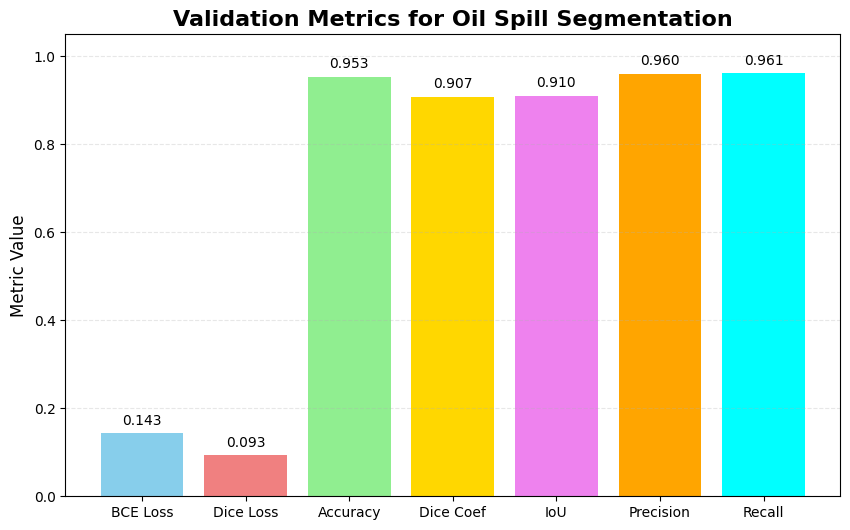

In [ ]:
import matplotlib.pyplot as plt

# Collect the metric results
metrics = {
    "BCE Loss": bce_loss_metric.result().numpy(),
    "Dice Loss": dice_loss_metric.result().numpy(),
    "Accuracy": accuracy_metric.result().numpy(),
    "Dice Coef": dice_metric_accum.result().numpy(),
    "IoU": iou_metric_accum.result().numpy(),
    "Precision": precision_metric.result().numpy(),
    "Recall": recall_metric.result().numpy()
}

# Plotting
plt.figure(figsize=(10,6))
bars = plt.bar(metrics.keys(), metrics.values(), color=['skyblue','lightcoral','lightgreen','gold','violet','orange','cyan'])
plt.title("Validation Metrics for Oil Spill Segmentation", fontsize=16, fontweight='bold')
plt.ylabel("Metric Value", fontsize=12)
plt.ylim(0, 1.05)  # For metrics normalized between 0 and 1

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f"{height:.3f}", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


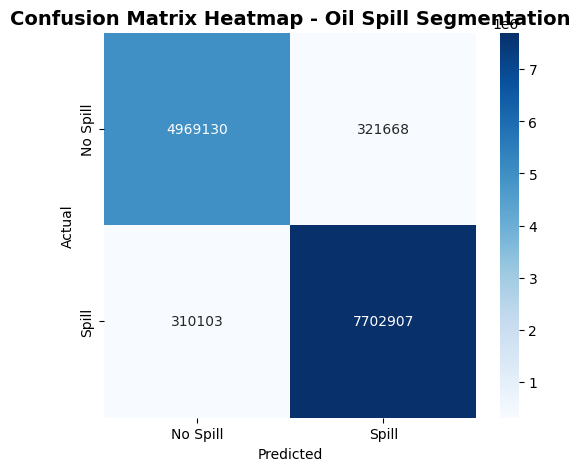

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accumulate all ground truths and predictions
all_true = []
all_pred = []

for images, masks in val_dataset:
    preds = model(images, training=False)
    preds_binary = tf.cast(preds > 0.5, tf.int32)  # Threshold to binary masks

    # Flatten batch-wise
    all_true.append(tf.reshape(masks, [-1]))
    all_pred.append(tf.reshape(preds_binary, [-1]))

# Concatenate all batches
y_true = tf.concat(all_true, axis=0).numpy()
y_pred = tf.concat(all_pred, axis=0).numpy()

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Spill", "Spill"],
            yticklabels=["No Spill", "Spill"])
plt.title("Confusion Matrix Heatmap - Oil Spill Segmentation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


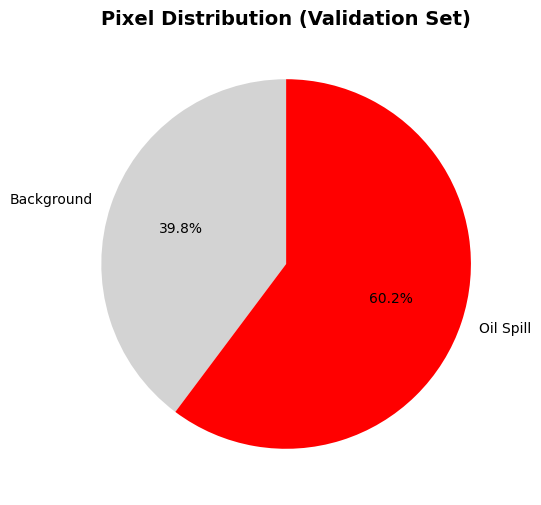

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Initialize counters
total_spill = 0
total_background = 0

# Iterate over the entire validation dataset
for images, masks in val_dataset:
    masks_np = masks.numpy()
    total_spill += (masks_np > 0.5).sum()
    total_background += (masks_np <= 0.5).sum()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie([total_background, total_spill],
        labels=["Background","Oil Spill"],
        autopct='%1.1f%%',
        colors=["lightgray","red"],
        startangle=90)
plt.title("Pixel Distribution (Validation Set)", fontsize=14, fontweight='bold')
plt.show()


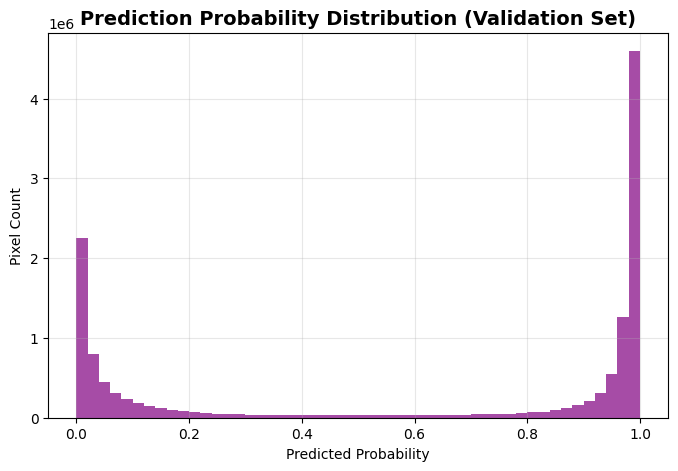

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Collect all predicted probabilities
all_preds = []

for images, masks in val_dataset:
    preds = model(images, training=False)  # Get predictions
    all_preds.append(preds.numpy().flatten())  # Flatten each batch

# Concatenate all predictions
all_preds = np.concatenate(all_preds)

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(all_preds, bins=50, color="purple", alpha=0.7)
plt.title("Prediction Probability Distribution (Validation Set)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Probability")
plt.ylabel("Pixel Count")
plt.grid(alpha=0.3)
plt.show()
